## Lab Practice Ensemble learning 1.0:  BOOTSTRAP (homework)  | Machine Learning II
#### ESU  Jan-2025
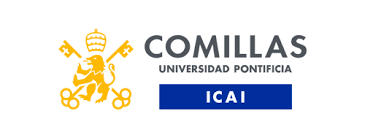

LEARNING OBJECTIVES
- How to perform the bootstrap approach
- How to review the botstrap results
- How to apply the bootstrap approach in a simple practical case

---
## Import modules

In [2]:
import numpy as np  # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # plotting
from scipy import stats # basic statistics

from sklearn.linear_model import LinearRegression
from sklearn.utils import resample  # allows implementing bootstrap

---
## 1. The bootstrap approach

Bootstrap is commonly used to quantify the uncertainty associated with a given estimator or statistical learning method. The bootstrap can be applied to many problems and methods, and is commonly used to estimate the standard errors of the coefficients estimated from model fits, or the distribution of error metrics, for example.

One of the great advantages of the bootstrap approach is that it can be applied in almost all situations. No complicated mathematical calculations
are required. Performing a bootstrap analysis entails only two steps: 

- First, decide which are the statistics of interest.
- Second, create a function that computes the statistic of interest (boot_function).
- Third, perform the bootstrap by repeatedly sampling observations from the data set with replacement.
- Fourth, analyse the bootstrap results to estimate the variability.

El bootstrap se utiliza comúnmente para cuantificar la incertidumbre asociada a un estimador o a un método de aprendizaje estadístico. Se puede aplicar a numerosos problemas y métodos, y es frecuentemente empleado para estimar los errores estándar de los coeficientes en modelos de ajuste, así como para obtener la distribución de métricas de error, entre otros usos.

¿Por qué es útil el bootstrap?

Una de las grandes ventajas del enfoque bootstrap es su aplicabilidad a casi cualquier situación. A diferencia de otros métodos más restrictivos, no requiere cálculos matemáticos complejos ni suposiciones fuertes sobre la distribución de los datos.

El procedimiento del bootstrap se puede resumir en cuatro pasos clave:

1.	Decidir cuál es la estadística de interés.

-   Puede tratarse de la media, la mediana, un coeficiente de regresión, una métrica de error como el RMSE, etc.

2.	Crear una función que calcule la estadística de interés (boot_function).

-	Esta función debe tomar un conjunto de datos como entrada y devolver el valor de la estadística seleccionada.

3.	Realizar el procedimiento bootstrap.

-	Se generan múltiples muestras con reemplazo a partir del conjunto de datos original.
-	Es decir, cada muestra bootstrap contiene la misma cantidad de observaciones que el conjunto original, pero algunas pueden aparecer varias veces mientras que otras pueden no aparecer en absoluto.

-	Se calcula la estadística de interés en cada muestra.
	
4.	Analizar los resultados del bootstrap para estimar la variabilidad.
-	Al analizar la distribución de los valores obtenidos a partir de las muestras bootstrap, se puede estimar la incertidumbre del estimador original.
-	Por ejemplo, calcular el intervalo de confianza o la desviación estándar de los coeficientes de un modelo.

Explicación intuitiva

Imagina que quieres estimar la altura media de los estudiantes de una universidad, pero solo tienes una muestra pequeña de 100 estudiantes. Si calculas la media directamente, no sabes cuánto podría variar esta estimación si hubieras tomado otra muestra.

Con bootstrap, simulas el proceso de re-muestreo repetido para ver cómo varía la media en distintas simulaciones, lo que te da una idea de la incertidumbre de tu estimación.

#### 1.1 Set the dataset

In [3]:
# create a basic original dataset
data = {'Name': ['Ines', 'Clara', 'Juan', 'Pedro'],
        'Age': [20, 21, 19, 18]}

df = pd.DataFrame(data)
df

,Name,Age
0,Ines,20
1,Clara,21
2,Juan,19
3,Pedro,18


#### 1.2 Set the function to compute the variables of interest. (BOOT FUNCTION)

In [5]:
# Create the function that computes the statistic of interest
def boot_function (df_bag):
    """
    Receives a dataframe with the bootstrapped resample (bag)
    Returns a new dataframe consisting of the values computed with the bag of data
    """
    # compute desired values from the particular bootstrapped sample
    boot_stats_1 = np.mean(df_bag.Age)
    boot_stats_2 = np.median(df_bag.Age)
    #boot_stats_3 = np.var(df_bag.Age)

    # save in a dataframe for output
    d = dict(stats_1=boot_stats_1, 
             stats_2=boot_stats_2)

    boot_stats = pd.DataFrame([d])
    
    return boot_stats

#### 1.3 Run the bootstrap approach to get the values of the variables of interest for each boot sample

In [6]:
# set the ramdom seed for reproductivility
np.random.seed(9999)

# Defining number of bootstrap (re)samples
n_boots = 1000

# Initializing DataFrame, to hold bootstrapped statistics
bootstrapped_stats = pd.DataFrame()

# In each iteration a bootstrap sample is formed
for i in range(n_boots):

    # sampling the original data in two sets: tr (train) and ts (test)
    train_set = resample(df,                # original dataframe for resampling
                         replace=True,      # sampling n_samples from data, with replacement
                         n_samples=len(df)) # the train_set sample has the same size than the original df
    
    # the test set consists of all observations not in train (usefull for computing OOB stats)
    test_set = df[~df.index.isin(train_set.index)]

    # show the bootstrap sample
    print(f'Boot {i} : ', '\tTRAIN =', train_set['Name'].tolist(), '\t\t\tTEST =', test_set['Name'].tolist())
    
    # compute bootstrapped stats using the training set
    bootstrapped_stats_i = boot_function(train_set)
    bootstrapped_stats = pd.concat(objs=[bootstrapped_stats, bootstrapped_stats_i])


Boot 0 :  	TRAIN = ['Juan', 'Clara', 'Juan', 'Clara'] 			TEST = ['Ines', 'Pedro']
Boot 1 :  	TRAIN = ['Pedro', 'Clara', 'Juan', 'Clara'] 			TEST = ['Ines']
Boot 2 :  	TRAIN = ['Ines', 'Clara', 'Clara', 'Juan'] 			TEST = ['Pedro']
Boot 3 :  	TRAIN = ['Pedro', 'Ines', 'Ines', 'Juan'] 			TEST = ['Clara']
Boot 4 :  	TRAIN = ['Ines', 'Ines', 'Clara', 'Juan'] 			TEST = ['Pedro']
Boot 5 :  	TRAIN = ['Clara', 'Pedro', 'Clara', 'Ines'] 			TEST = ['Juan']
Boot 6 :  	TRAIN = ['Juan', 'Pedro', 'Juan', 'Ines'] 			TEST = ['Clara']
Boot 7 :  	TRAIN = ['Pedro', 'Ines', 'Ines', 'Juan'] 			TEST = ['Clara']
Boot 8 :  	TRAIN = ['Ines', 'Ines', 'Ines', 'Clara'] 			TEST = ['Juan', 'Pedro']
Boot 9 :  	TRAIN = ['Juan', 'Pedro', 'Clara', 'Pedro'] 			TEST = ['Ines']
Boot 10 :  	TRAIN = ['Clara', 'Juan', 'Pedro', 'Juan'] 			TEST = ['Ines']
Boot 11 :  	TRAIN = ['Clara', 'Pedro', 'Pedro', 'Clara'] 			TEST = ['Ines', 'Juan']
Boot 12 :  	TRAIN = ['Pedro', 'Clara', 'Clara', 'Clara'] 			TEST = ['Ines', 'Juan']
Boot 13

#### 1.4 Analyse the bootstrap values to estimate the variability with the sample of the variables of interest

Head of the dataframe with the bootstrapped values:
   stats_1  stats_2
0    20.00     20.0
0    19.75     20.0
0    20.25     20.5
0    19.25     19.5
0    20.00     20.0
Evolution with the bootstrap sample


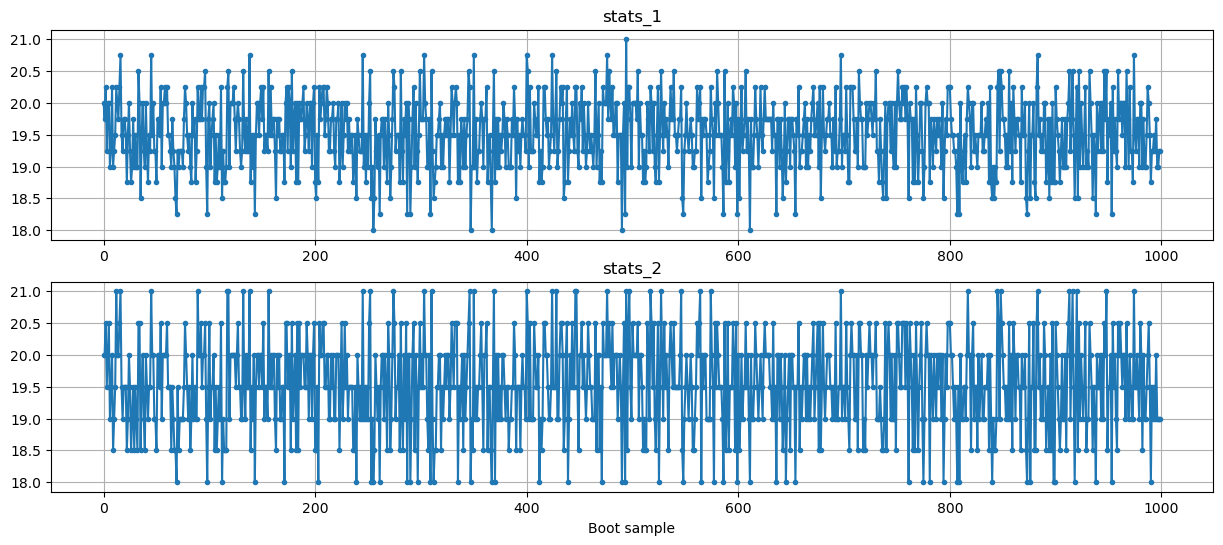

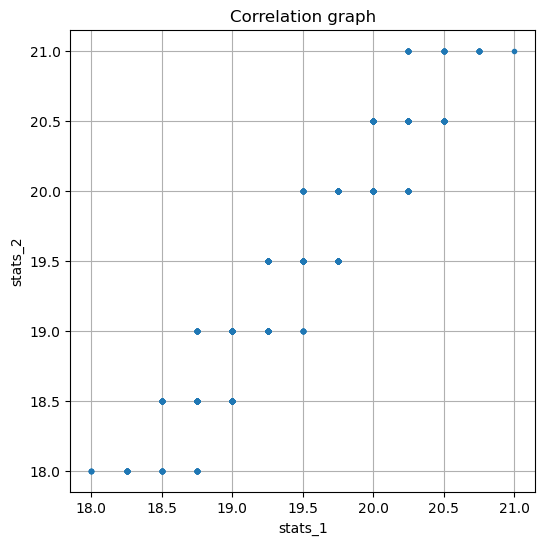

In [7]:
# Graficamos los estadísticos (en este caso la media y la mediana) para cada una de las muestras bootstrap.

# Use the bootstrapped_stats to study the variability of the computed stats
print('Head of the dataframe with the bootstrapped values:')
print(bootstrapped_stats.head())

print('Evolution with the bootstrap sample')
fig = plt.figure(1, figsize=(15, 6)) 
plt.subplot(2,1,1)
plt.plot(bootstrapped_stats.stats_1.to_list(), '.-')
plt.title('stats_1')
plt.grid()
plt.subplot(2,1,2)
plt.plot(bootstrapped_stats.stats_2.to_list(), '.-')
plt.title('stats_2')
plt.xlabel('Boot sample')
plt.grid()
plt.show()

## Correlación entre la media y la mediana
fig = plt.figure(2, figsize=(6, 6)) 
plt.plot(bootstrapped_stats.stats_1.to_list(), bootstrapped_stats.stats_2.to_list(), '.')
plt.xlabel('stats_1')
plt.ylabel('stats_2')
plt.title('Correlation graph')
plt.grid()
plt.show()


Main descriptive statistics:
           stats_1      stats_2
count  1000.000000  1000.000000
mean     19.522750    19.536500
std       0.549064     0.733113
min      18.000000    18.000000
10%      18.750000    18.500000
25%      19.250000    19.000000
50%      19.500000    19.500000
75%      20.000000    20.000000
90%      20.250000    20.500000
max      21.000000    21.000000

Correlation matrix:
         stats_1  stats_2
stats_1   1.0000   0.9423
stats_2   0.9423   1.0000

Empirical distribution of the stats:


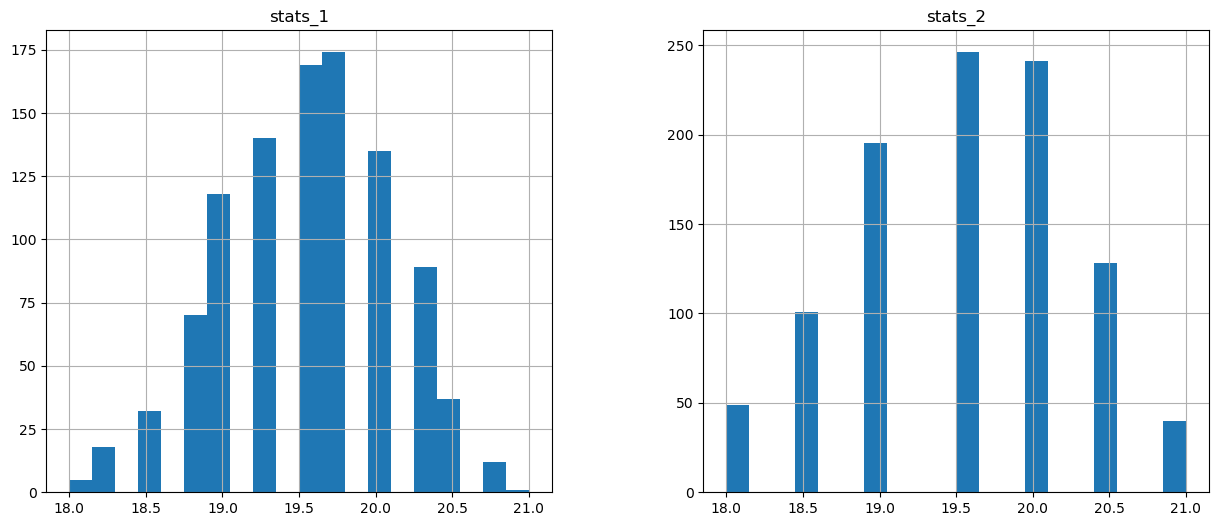

In [8]:
# Results from the bootstrap

# Overview of the stats
print('Main descriptive statistics:')
print(bootstrapped_stats.describe(percentiles=[0.1,0.25,0.75,0.9]))

# correlation matrix
mat_corr = bootstrapped_stats.corr()
print('\nCorrelation matrix:')
print(np.round(mat_corr, 4))

# histograms
print('\nEmpirical distribution of the stats:')
bootstrapped_stats.hist(figsize=(15, 6), bins = 20, sharex = False)
plt.draw()

---
### 2. A Simple case: Variance of the Sample Mean Estimator

The sampling distribution of a mean is generated by repeated sampling from the same population and recording of the sample means obtained. This forms a distribution of different means, and this distribution has its own mean and variance. Theory says that the variance of the sampling mean distribution obtained is equal to the variance of the population divided by the sample size.

La distribución de muestreo de la media es un concepto fundamental en estadística. Aquí te lo explico paso a paso:
Imagina que tienes una población grande (por ejemplo, las alturas de todos los adultos en un país).
Tomas muchas muestras diferentes de esta población, cada una de un tamaño específico (por ejemplo, 100 personas).
Para cada muestra, calculas la media.
Si haces esto muchas veces, obtendrás muchas medias diferentes.
Estas medias forman una nueva distribución, llamada "distribución de muestreo de la media".

#### 2.1 Create the simulated data

In [9]:
# set the ramdom seed for reproductivility
np.random.seed(99999)

In [10]:
# 1. Definición de la distribución verdadera (población) Y obtención de una muestra.


# TRUE (UNKNOWN) DISTRIBUTION (i.e. POPULATION) random variable ~ Normal(mu = 10, std = 2)

# create random variable 
mean_true = 10
std_true = 2
var_true = std_true**2
RV = stats.norm(loc = mean_true, scale = std_true)

# Se genera una muestra aleatoria de tamaño 10,000 a partir de la distribución definida en RV. 
# Importante: Aunque y sigue la distribución normal con la que fue generada, es una muestra finita, por lo que su media y varianza no serán 
# exactamente las de la población ( \mu = 10, \sigma^2 = 4 ), pero deberían ser similares.
# sample
# random sample from the random variable (random variates)
sample_size = 10000
y = RV.rvs(size = sample_size)
y

array([11.24818809, 12.54992617,  6.68079278, ..., 14.75920515,
        8.3961993 ,  8.02738452], shape=(10000,))

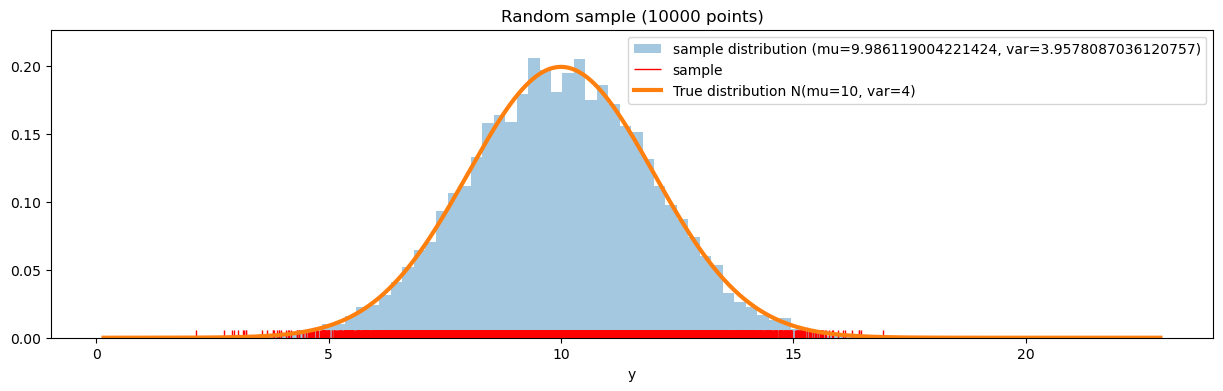

In [11]:
# Graficamos la distribución verdadera y la muestra generada.

# plot histogram of y for visual checking
xs = np.linspace(min(y)-np.std(y),max(y)+3*np.std(y), 1000)

#pdf_true: Se evalúa la función de densidad de probabilidad (PDF) de la distribución normal verdadera en esos puntos.
pdf_true = RV.pdf(xs)

fig = plt.figure(1, figsize=(15, 4))
# Histograma de la muestra.
plt.hist(y, bins=60, density = True, alpha = 0.4, label = f'sample distribution (mu={np.mean(y)}, var={np.var(y)})')
# Muestra la posición de cada punto de la muestra a lo largo del eje  x .
sns.rugplot(y, color='r', label = 'sample')
# Superponemos las PDF verdadera
plt.plot(xs, pdf_true, linewidth = 3, label=f'True distribution N(mu={mean_true}, var={var_true})')
plt.xlabel('y')
plt.legend()
plt.title(f'Random sample ({len(y)} points)')
plt.show()

#### 2.2. The Sample mean estimator (basic in statistical inference)
see https://en.wikipedia.org/wiki/Sample_mean_and_covariance

In [12]:
# Definimos la distribución de la media muestral teórica.

# THEORETICAL SAMPLE MEAN ESTIMATOR

# create random variable
# Esperanza de la media muestral (coincide con la media verdadera de la población)
mean_sm_theo = mean_true

# La varianza de la media muestral se obtiene dividiendo la varianza de la población entre el tamaño de la muestra:
var_sm_theo = var_true / sample_size  # variance of the sample mean estimator (theoretical result)
std_sm_theo = np.sqrt(var_sm_theo) # desviación estándar de la media muestral

# Aquí, se define una nueva variable aleatoria normal que representa la distribución de la media muestral
SM_theo = stats.norm(loc = mean_sm_theo, scale = std_sm_theo)

In [14]:
## Aquí hacemos lo mismo pero a partir de la muestra


# Estimate from the sample the mean and variance of the sample mean estimator 
mean_sample = np.mean(y)
var_sample = np.var(y)

# estimates of the mean and variance of the estimator (empirical)
mean_sm_emp = mean_sample

var_sm_emp = var_sample / sample_size  # variance of the sample mean estimator (theoretical result)
std_sm_emp = np.sqrt(var_sm_emp)

# SAMPLE ESTIMATOR DISTRIBUTION with params estimated from the sample. Los paráemtros están estimados a partir de la muestra
SM_emp = stats.norm(loc = mean_sm_emp, scale = std_sm_emp)


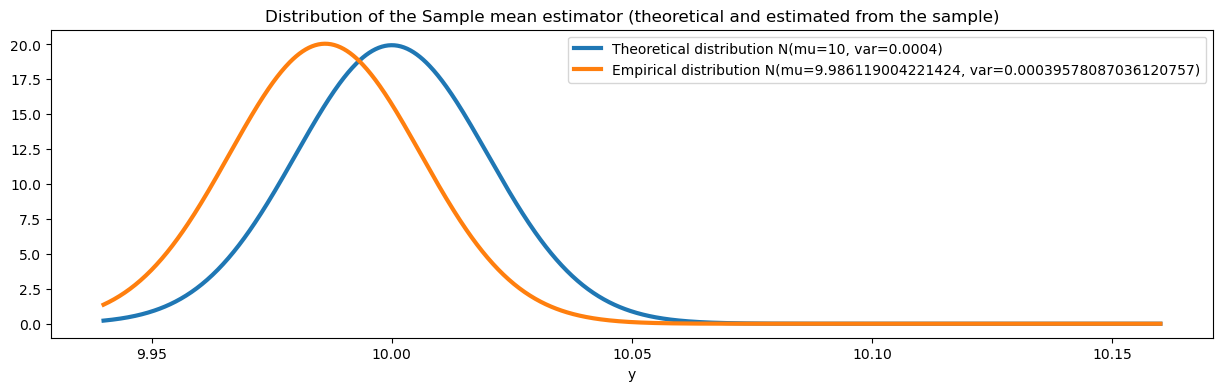

In [15]:
# plot theoretical distribution of the sample mean estimator
xs = np.linspace(SM_theo.mean()-3*SM_theo.std(),SM_theo.mean()+8*SM_theo.std(), 1000)
pdf_SM_theo = SM_theo.pdf(xs)
pdf_SM_emp = SM_emp.pdf(xs)

fig = plt.figure(1, figsize=(15, 4))
plt.plot(xs, pdf_SM_theo, linewidth = 3, label=f'Theoretical distribution N(mu={mean_sm_theo}, var={var_sm_theo})')
plt.plot(xs, pdf_SM_emp, linewidth = 3, label=f'Empirical distribution N(mu={mean_sm_emp}, var={var_sm_emp})')
plt.xlabel('y')
plt.legend()
plt.title('Distribution of the Sample mean estimator (theoretical and estimated from the sample)')
plt.show()

##### 2.3 Apply the bootstrap approach

In [16]:
# Prepare the dataframe for easy 
data = {'y': y}
df = pd.DataFrame(data)
df

,y
0,11.248188
1,12.549926
2,6.680793
3,11.015900
4,9.558172
...,...
9995,7.309307
9996,9.246731
9997,14.759205
9998,8.396199


In [17]:
## Funciones que queremos calcular en bootstrap

# Create the function that computes the mean and variance
def boot_function_mean_var (df_bag):
    """
    Receives a dataframe with the bootstrapped resample (bag)
    Returns a new dataframe consisting of the values computed with the bag of data
    """
    # compute desired values from the particular bootstrapped sample
    boot_stats_1 = np.mean(df_bag.y)
    boot_stats_2 = np.var(df_bag.y)

    # save in a dataframe for output
    d = dict(stats_1=boot_stats_1, 
             stats_2=boot_stats_2)

    boot_stats = pd.DataFrame([d])
    
    return boot_stats

In [18]:
# check the function
st = boot_function_mean_var(df.iloc[:100])
st

,stats_1,stats_2
0,10.151379,4.014722


In [19]:
# Corremos bootstrap.

# set the ramdom seed for reproductivility
np.random.seed(99999)

# Defining number of bootstrap (re)samples
n_boots = 5000

# Initializing DataFrame, to hold bootstrapped statistics
bootstrapped_stats = pd.DataFrame()

# In each iteration a bootstrap sample is formed
for i in range(n_boots):

    # sampling the original data in two sets: tr (train) and ts (test)
    train_set = resample(df,                # original dataframe for resampling
                         replace=True,      # sampling n_samples from data, with replacement
                         n_samples=len(df)) # the train_set sample has the same size than the original df
    
    # the test set consists of all observations not in train (usefull for computing OOB stats)
    test_set = df[~df.index.isin(train_set.index)]
    
    # compute bootstrapped stats using the training set
    bootstrapped_stats_i = boot_function_mean_var(train_set)
    bootstrapped_stats = pd.concat(objs=[bootstrapped_stats, bootstrapped_stats_i])

Main descriptive statistics:
           stats_1      stats_2
count  5000.000000  5000.000000
mean      9.985838     3.955776
std       0.019686     0.055246
min       9.916836     3.744325
10%       9.960699     3.883392
25%       9.972562     3.918762
50%       9.985537     3.957386
75%       9.999277     3.993417
90%      10.010793     4.025316
max      10.061128     4.139769

Correlation matrix:
         stats_1  stats_2
stats_1   1.0000  -0.0212
stats_2  -0.0212   1.0000

Empirical distribution of the stats:


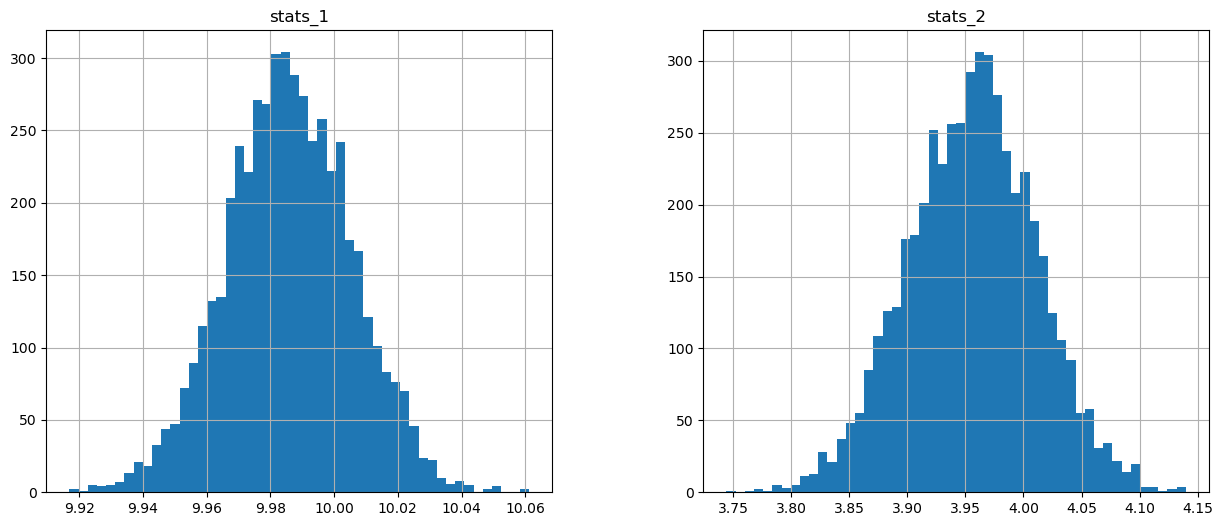

In [20]:
# Estadísticas

# Overview of the stats
print('Main descriptive statistics:')
print(bootstrapped_stats.describe(percentiles=[0.1,0.25,0.75,0.9]))

# correlation matrix
mat_corr = bootstrapped_stats.corr()
print('\nCorrelation matrix:')
print(np.round(mat_corr, 4))

# histograms
print('\nEmpirical distribution of the stats:')
bootstrapped_stats.hist(figsize=(15, 6), bins = 50, sharex = False)
plt.draw()

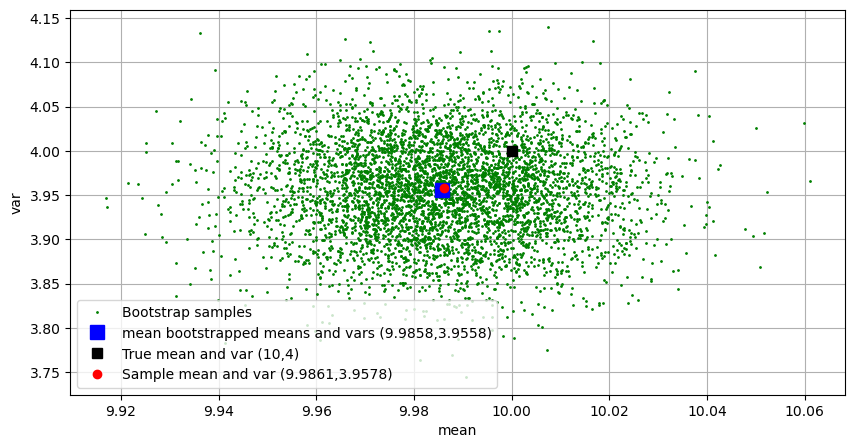

In [22]:
# Compare variance of the mean estimator according to bootstrap and theory
mean_boots_means = np.mean(bootstrapped_stats.stats_1)
mean_boots_vars =  np.mean(bootstrapped_stats.stats_2)

# Show all the statistics together
fig = plt.figure(1, figsize=(10, 5))
plt.plot(bootstrapped_stats.stats_1, bootstrapped_stats.stats_2, '.', color='g', markersize = 2, label = 'Bootstrap samples')
plt.plot(mean_boots_means, mean_boots_vars, 's', color='b', markersize = 10, label = f'mean bootstrapped means and vars ({np.round(mean_boots_means,4)},{np.round(mean_boots_vars,4)})')
plt.plot(mean_true, var_true, 's', color='k', markersize = 7, label = f'True mean and var ({mean_true},{var_true})')
plt.plot(mean_sample, var_sample, 'o', color='r', markersize = 6, label = f'Sample mean and var ({np.round(mean_sample,4)},{np.round(var_sample,4)})')
plt.xlabel('mean')
plt.ylabel('var')
plt.legend()
plt.grid()
plt.show()

### 3. repeat section 2. varying the seed (np.random.seed(99999)) and see if the results change with the original sample